# Exploratory Data Analysis: Citation Impact Prediction

This notebook explores the dataset used to predict whether a paper is high-impact.

Goals:
- Understand dataset structure and class balance
- Analyze feature distributions
- Identify predictive features
- Detect and remove leakage-prone variables
- Select features for modeling

### Imports + Setup

In [60]:
import pandas as pd
import matplotlib.pyplot as plt

### Load data

In [61]:
df = pd.read_csv("../data/processed/papers.csv")

print("Shape:", df.shape)
df.head()

Shape: (5277, 18)


,paper_id,publication_year,cited_by_count,num_authors,num_institutions,num_countries,is_multi_institution,is_international,has_elite_affiliation,has_industry,has_gov_nonprofit,has_us_institution,is_open_access,is_journal,high_impact,log_num_authors,log_num_institutions,log_num_countries
0,https://openalex.org/W2784446974,2018,0,1,0,0,0,0,0,0,0,0,1,0,0,0.693147,0.000000,0.000000
1,https://openalex.org/W2971141423,2018,0,1,0,0,0,0,0,0,0,0,0,0,0,0.693147,0.000000,0.000000
2,https://openalex.org/W2897768195,2018,10,5,2,1,1,0,0,0,0,0,0,0,0,1.791759,1.098612,0.693147
3,https://openalex.org/W2908411605,2018,22,4,3,2,1,1,0,0,0,0,0,1,0,1.609438,1.386294,1.098612
4,https://openalex.org/W2904708266,2018,0,1,0,0,0,0,0,0,0,0,0,1,0,0.693147,0.000000,0.000000


### Data overview

In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5277 entries, 0 to 5276
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   paper_id               5277 non-null   object 
 1   publication_year       5277 non-null   int64  
 2   cited_by_count         5277 non-null   int64  
 3   num_authors            5277 non-null   int64  
 4   num_institutions       5277 non-null   int64  
 5   num_countries          5277 non-null   int64  
 6   is_multi_institution   5277 non-null   int64  
 7   is_international       5277 non-null   int64  
 8   has_elite_affiliation  5277 non-null   int64  
 9   has_industry           5277 non-null   int64  
 10  has_gov_nonprofit      5277 non-null   int64  
 11  has_us_institution     5277 non-null   int64  
 12  is_open_access         5277 non-null   int64  
 13  is_journal             5277 non-null   int64  
 14  high_impact            5277 non-null   int64  
 15  log_

In [63]:
df.describe()

,publication_year,cited_by_count,num_authors,num_institutions,num_countries,is_multi_institution,is_international,has_elite_affiliation,has_industry,has_gov_nonprofit,has_us_institution,is_open_access,is_journal,high_impact,log_num_authors,log_num_institutions,log_num_countries
count,5277.000000,5277.000000,5277.000000,5277.000000,5277.000000,5277.000000,5277.000000,5277.000000,5277.000000,5277.000000,5277.000000,5277.000000,5277.000000,5277.000000,5277.000000,5277.000000,5277.000000
mean,2018.998484,10.415009,3.160697,1.135683,0.777904,0.266060,0.120902,0.046807,0.038279,0.036953,0.103089,0.423157,0.585370,0.103089,1.264156,0.589810,0.484059
std,0.816340,39.589236,4.339238,1.653267,0.817004,0.441938,0.326044,0.211245,0.191888,0.188664,0.304104,0.494107,0.492705,0.304104,0.496375,0.551586,0.422641
min,2018.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.693147,0.000000,0.000000
25%,2018.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.693147,0.000000,0.000000
50%,2019.000000,1.000000,2.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.098612,0.693147,0.693147
75%,2020.000000,7.000000,4.000000,2.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.609438,1.098612,0.693147
max,2020.000000,1293.000000,100.000000,51.000000,12.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,4.615121,3.951244,2.564949


### Target analysis

In [64]:
class_counts = df["high_impact"].value_counts()
class_props = df["high_impact"].value_counts(normalize=True)

print(class_counts)
print(class_props)

high_impact
0    4733
1     544
Name: count, dtype: int64
high_impact
0    0.896911
1    0.103089
Name: proportion, dtype: float64


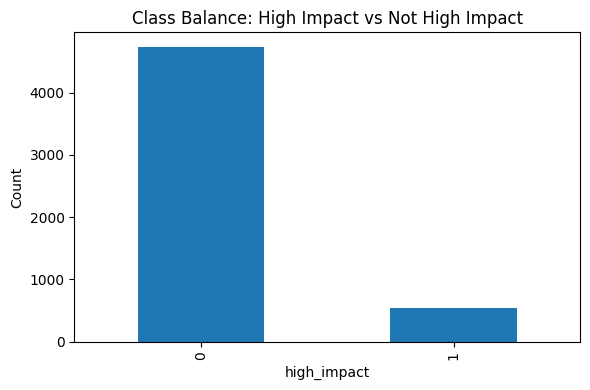

In [65]:
plt.figure(figsize=(6, 4))
class_counts.plot(kind="bar")
plt.title("Class Balance: High Impact vs Not High Impact")
plt.xlabel("high_impact")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("../results/class_balance.png")
plt.show()

### Citation distribution

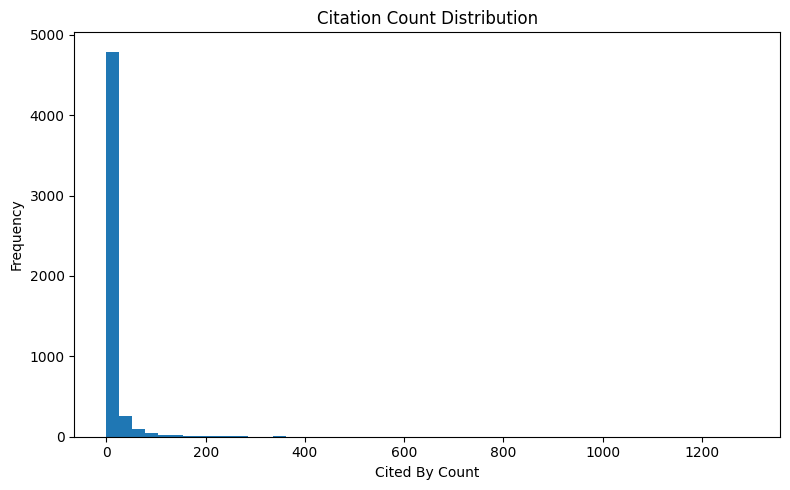

In [66]:
plt.figure(figsize=(8, 5))
plt.hist(df["cited_by_count"], bins=50)
plt.title("Citation Count Distribution")
plt.xlabel("Cited By Count")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("../results/citation_distribution.png")
plt.show()

### Log feature transformation
Many of the collaboration features (authors, institutions, countries) are highly skewed. Log transformations are applied to reduce skew and stabilize learning.

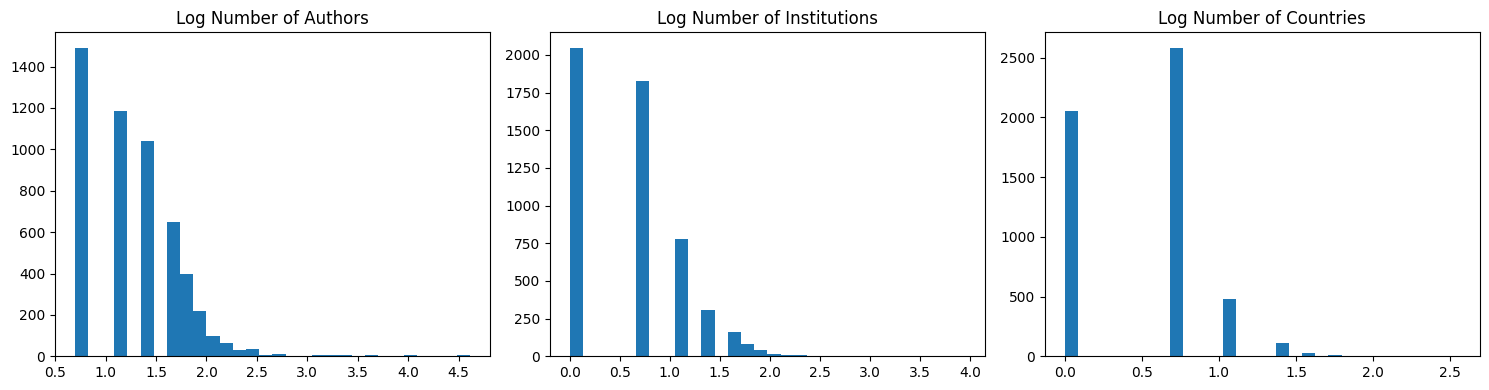

In [67]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df["log_num_authors"], bins=30)
axes[0].set_title("Log Number of Authors")

axes[1].hist(df["log_num_institutions"], bins=30)
axes[1].set_title("Log Number of Institutions")

axes[2].hist(df["log_num_countries"], bins=30)
axes[2].set_title("Log Number of Countries")

plt.tight_layout()
plt.savefig("../results/log_feature_distributions.png")
plt.show()

### Correlation analysis

In [68]:
target_corr = df.corr(numeric_only=True)["high_impact"].sort_values(ascending=False)
target_corr

high_impact              1.000000
cited_by_count           0.538410
log_num_institutions     0.296870
log_num_countries        0.275338
num_countries            0.270681
num_institutions         0.262833
is_multi_institution     0.254226
is_international         0.229830
log_num_authors          0.187634
has_elite_affiliation    0.160908
has_us_institution       0.135103
is_journal               0.113290
num_authors              0.080663
has_industry             0.078526
has_gov_nonprofit        0.069037
publication_year        -0.000897
is_open_access          -0.053228
Name: high_impact, dtype: float64

Key observations:
- Collaboration metrics (institutions, countries, authors) show strongest correlation
- Elite affiliation is positively associated with impact
- Citation-related variables are strongly correlated but can't be used bcs of leakage

### Binary Feature Analysis

In [69]:
binary_features = [
    "is_multi_institution",
    "is_international",
    "has_elite_affiliation",
    "has_industry",
    "has_gov_nonprofit",
    "has_us_institution",
    "is_open_access",
    "is_journal",
]

binary_summary = df.groupby("high_impact")[binary_features].mean().T
binary_summary

high_impact,0,1
is_multi_institution,0.227974,0.597426
is_international,0.095500,0.341912
has_elite_affiliation,0.035284,0.147059
has_industry,0.033171,0.082721
has_gov_nonprofit,0.032538,0.075368
has_us_institution,0.089161,0.224265
is_open_access,0.432073,0.345588
is_journal,0.566448,0.750000


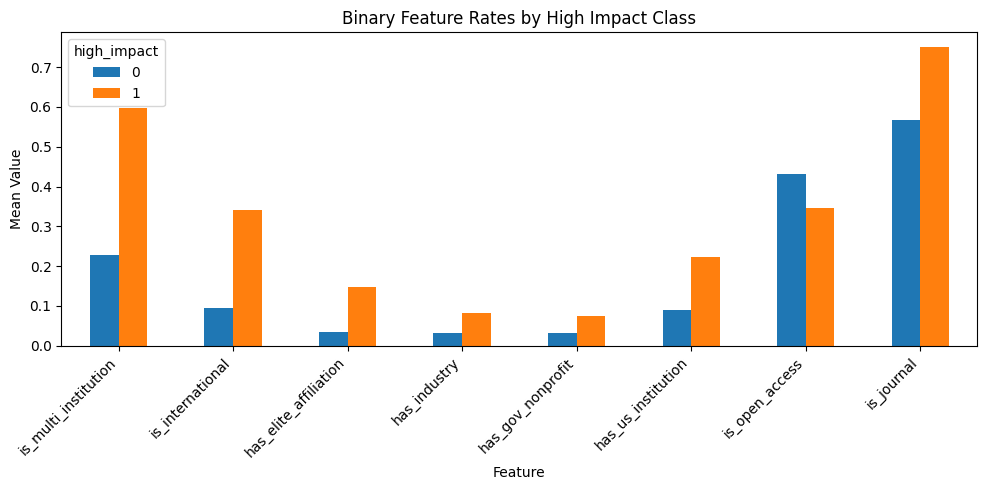

In [70]:
binary_summary.plot(kind="bar", figsize=(10, 5))
plt.title("Binary Feature Rates by High Impact Class")
plt.xlabel("Feature")
plt.ylabel("Mean Value")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../results/binary_feature_rates.png")
plt.show()

### Leakage

In [72]:
print(df[["cited_by_count", "high_impact"]].corr())

                cited_by_count  high_impact
cited_by_count         1.00000      0.53841
high_impact            0.53841      1.00000


### Feature Selection

In [74]:
selected_features = [
    "log_num_authors",
    "log_num_institutions",
    "log_num_countries",
    "is_multi_institution",
    "is_international",
    "has_elite_affiliation",
    "has_us_institution",
    "is_journal",
    "has_industry",
    "has_gov_nonprofit",
    "is_open_access",
]

excluded_features = [
    "paper_id",
    "cited_by_count",
    "publication_year",
]

print("Selected features:")
print(selected_features)

print("\nExcluded features:")
print(excluded_features)

Selected features:
['log_num_authors', 'log_num_institutions', 'log_num_countries', 'is_multi_institution', 'is_international', 'has_elite_affiliation', 'has_us_institution', 'is_journal', 'has_industry', 'has_gov_nonprofit', 'is_open_access']

Excluded features:
['paper_id', 'cited_by_count', 'publication_year']


### Takeaways

- The dataset is highly imbalanced (~10% high-impact papers)
- Collaboration features (authors, institutions, countries) provide the strongest signal
- Elite affiliation is associated with higher impact
- Citation-based features are excluded due to leakage
- Log transformations improve feature usability by reducing skew

These insights will guide our feature selection and model design.